# Dataset Tutorial: Superposition-Coded Physical-Layer Tag Datasets

This notebook shows how to open and use the two HDF5 files in `data/`:

1. **`data/encryption/superposition_encryption_alpha0.5_R0.5.h5`** — the message
   is superposed (alpha=0.5) with an AES-CTR keystream acting as the tag,
   transmitted Source -> Relay -> Destination over USRP SDRs. Contains
   `destination` and `relay` groups.
2. **`data/alpha_sweep/superposition_alpha_sweep_R0.5.h5`** — the same fixed
   message + tag superposition scheme (no encryption), swept across
   superposition coefficients alpha in {0.0, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4}
   at R=0.5, destination-only. Useful for developing/benchmarking a joint
   message+tag demodulator across SNR and alpha.

See `README.md` at the repository root for full field descriptions,
the physical setup, and known caveats.

In [1]:
from pathlib import Path
import json

import h5py
import numpy as np

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

DATA_DIR = Path.cwd().parent / "data" if Path.cwd().name == "notebooks" else Path.cwd() / "data"
ENCRYPTION_H5 = DATA_DIR / "encryption" / "superposition_encryption_alpha0.5_R0.5.h5"
ALPHA_SWEEP_H5 = DATA_DIR / "alpha_sweep" / "superposition_alpha_sweep_R0.5.h5"
print(ENCRYPTION_H5, ENCRYPTION_H5.exists())
print(ALPHA_SWEEP_H5, ALPHA_SWEEP_H5.exists())

/home/moh/Documents/PhD/Kim/Securing Wireless Relay/dataset_release/data/encryption/superposition_encryption_alpha0.5_R0.5.h5 True
/home/moh/Documents/PhD/Kim/Securing Wireless Relay/dataset_release/data/alpha_sweep/superposition_alpha_sweep_R0.5.h5 True


## 1. Helper functions (shared by both files)

Each file is organized as one or more named **groups** (e.g. `destination`, `relay`, or `alpha_0.10`), and every group has the same internal layout:

```
<group>/documents/id, SNR, BER_tag, BER_msg, sigma_n2, config_json, [time_stamp], [enc_conf_json]
<group>/arrays/r0_data + r0_lengths, r1_data + r1_lengths   (flattened variable-length arrays)
```

In [2]:
def decode_strings(values):
    decoded = []
    for value in values:
        if isinstance(value, (bytes, np.bytes_)):
            decoded.append(value.decode('utf-8'))
        else:
            decoded.append(str(value))
    return decoded

def lengths_to_offsets(lengths):
    lengths = np.asarray(lengths, dtype=np.int64)
    offsets = np.empty(len(lengths) + 1, dtype=np.int64)
    offsets[0] = 0
    offsets[1:] = np.cumsum(lengths)
    return offsets

def list_groups(h5_path):
    with h5py.File(h5_path, 'r') as f:
        return list(f.keys()), dict(f.attrs)

def group_metadata_table(h5_path, group_name):
    with h5py.File(h5_path, 'r') as f:
        g = f[group_name]
        data = {
            'id': decode_strings(g['documents/id'][:]),
            'SNR': g['documents/SNR'][:],
            'BER_tag': g['documents/BER_tag'][:],
            'BER_msg': g['documents/BER_msg'][:],
            'sigma_n2': g['documents/sigma_n2'][:],
            'r0_len': g['arrays/r0_lengths'][:],
            'r1_len': g['arrays/r1_lengths'][:],
        }
        if 'time_stamp' in g['documents']:
            data['time_stamp'] = decode_strings(g['documents/time_stamp'][:])
        if pd is not None:
            return pd.DataFrame(data)
        return data

def get_document(h5_path, group_name, index):
    with h5py.File(h5_path, 'r') as f:
        g = f[group_name]
        r0_offsets = lengths_to_offsets(g['arrays/r0_lengths'][:])
        r1_offsets = lengths_to_offsets(g['arrays/r1_lengths'][:])
        doc = {
            'id': decode_strings([g['documents/id'][index]])[0],
            'SNR': float(g['documents/SNR'][index]),
            'BER_tag': float(g['documents/BER_tag'][index]),
            'BER_msg': float(g['documents/BER_msg'][index]),
            'sigma_n2': float(g['documents/sigma_n2'][index]),
            'config': json.loads(decode_strings([g['documents/config_json'][index]])[0]),
            'r0': g['arrays/r0_data'][int(r0_offsets[index]):int(r0_offsets[index+1])],
            'r1': g['arrays/r1_data'][int(r1_offsets[index]):int(r1_offsets[index+1])],
        }
        if 'time_stamp' in g['documents']:
            doc['time_stamp'] = decode_strings([g['documents/time_stamp'][index]])[0]
        if 'enc_conf_json' in g['documents']:
            doc['enc_conf'] = json.loads(decode_strings([g['documents/enc_conf_json'][index]])[0])
        return doc

## 2. Encryption dataset: groups and attrs

In [3]:
groups, attrs = list_groups(ENCRYPTION_H5)
print('groups:', groups)
print('file attrs:', attrs)
group_metadata_table(ENCRYPTION_H5, 'destination').head() if pd is not None else group_metadata_table(ENCRYPTION_H5, 'destination')

groups: ['destination', 'relay']
file attrs: {'alpha': np.float64(0.5), 'code_rate_R': np.float64(0.5), 'created_at_utc': '2026-09-17T20:33:40.903345+00:00', 'dataset_name': 'Superposition-Coded MAC-Tag with AES-CTR Keystream Tag (alpha=0.5, R=0.5)'}


,id,SNR,BER_tag,BER_msg,sigma_n2,r0_len,r1_len,time_stamp
0,68b6188e214a95347915baed,11.663487,0.0,0.0,1.087897e-07,14976,14976,1756764302.6688986
1,68b618a1214a95347915baf3,11.929620,0.0,0.0,1.084267e-07,14976,14976,1756764321.9814007
2,68b618b4214a95347915baf9,10.619855,0.0,0.0,1.083026e-07,14976,14976,1756764340.9038599
3,68b618c7214a95347915baff,11.612038,0.0,0.0,1.093247e-07,14976,14976,1756764359.9846969
4,68b618da214a95347915bb05,11.505278,0.0,0.0,1.095413e-07,14976,14976,1756764378.873653


### Inspect one document (destination) and its enc_conf

In [4]:
doc = get_document(ENCRYPTION_H5, 'destination', 0)
{k: (v if k not in ('r0', 'r1') else f'array[{len(v)}] head={v[:5].tolist()}') for k, v in doc.items()}

{'id': '68b6188e214a95347915baed',
 'SNR': 11.66348706621725,
 'BER_tag': 0.0,
 'BER_msg': 0.0,
 'sigma_n2': 1.087897329597551e-07,
 'config': {'ACQ_TIME': 1.7,
  'ALPHA': 0.5,
  'DESTINATION': '8000182',
  'FREQ': 1900000000,
  'FREQ_DEV': 100000,
  'IN_CHAMBER': False,
  'LPF_CUTOFF': 600000,
  'MAC_KEY': 'key',
  'MAC_LDPC': 0.3333333333333333,
  'MAC_REP': 0.05263157894736842,
  'MAC_SHA': 'sha256',
  'MIMO': False,
  'MSG_CODE_RATE': 0.5,
  'MongoDB_Collection_name': 'r0_r1',
  'PAYLOAD': 'This message is the default payload for the tests, and is 5504 bits long. It will be superposed with MAC tag of 256 bits with 1/45 code rate, which makes the codeword length of 11520.0.This message is the default payload for the tests, and is 5504 bits long. It will be superposed with MAC tag of 256 bits with 1/45 code rate, which makes the codeword length of 11520.0.This message is the default payload for the tests, and is 5504 bits long. It will be superposed with MAC tag of 256 bits with 1/45

### Reconstruct the ground-truth tag from enc_conf

The tag superposed on the message is not a stored bit array — it is an
AES-CTR keystream chunk derived from `enc_conf['KEY']`, `enc_conf['IV']`,
and `enc_conf['COUNTER']`. `scripts/verify_keystream.py` reimplements the
transmitter's keystream slicing so you can regenerate that exact bit
sequence and score your decoder against it. See that script's caveat about
COUNTER being a live-shared value, not a per-frame-verified index.

In [5]:
import sys
SCRIPTS_DIR = Path.cwd().parent / 'scripts' if Path.cwd().name == 'notebooks' else Path.cwd() / 'scripts'
sys.path.append(str(SCRIPTS_DIR))
from verify_keystream import keystream_bits

tag_bits = keystream_bits(doc['enc_conf']['KEY'], doc['enc_conf']['IV'], doc['enc_conf']['COUNTER'], len(doc['r0']))
tag_bits[:32]

array([0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 1], dtype=uint8)

## 3. Alpha-sweep dataset: compare SNR / BER across alpha

In [6]:
groups, attrs = list_groups(ALPHA_SWEEP_H5)
print('groups:', groups)
print('file attrs:', attrs)

tables = {g: group_metadata_table(ALPHA_SWEEP_H5, g) for g in groups}
if pd is not None:
    summary = pd.DataFrame({
        g: {'n_docs': len(t), 'SNR_min': t['SNR'].min(), 'SNR_max': t['SNR'].max()}
        for g, t in tables.items()
    }).T
    summary
else:
    summary = {g: (len(t['SNR']), min(t['SNR']), max(t['SNR'])) for g, t in tables.items()}
    summary

groups: ['alpha_0.00', 'alpha_0.10', 'alpha_0.15', 'alpha_0.20', 'alpha_0.25', 'alpha_0.30', 'alpha_0.35', 'alpha_0.40']
file attrs: {'alphas': array([0.  , 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 ]), 'code_rate_R': np.float64(0.5), 'created_at_utc': '2026-09-17T20:33:51.347680+00:00', 'dataset_name': 'Superposition-Coded Fixed Message + Tag, Alpha Sweep (R=0.5, no encryption)'}


## 4. Optional quick plot: BER_tag vs SNR, one line per alpha

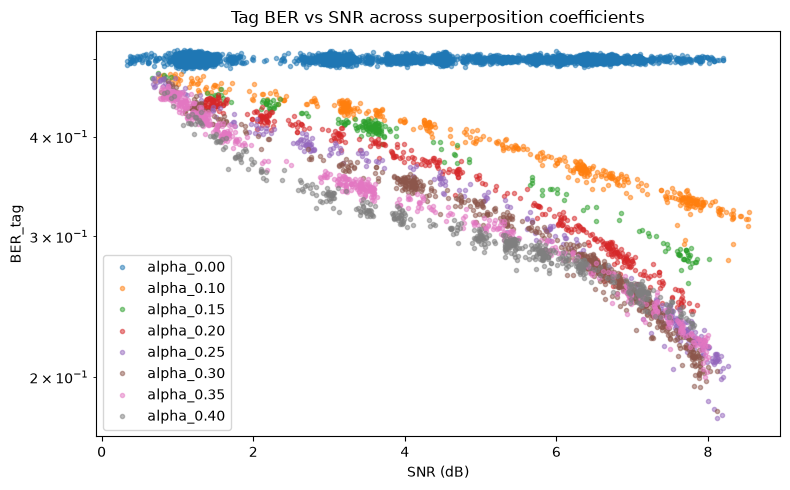

In [7]:
if plt is None:
    print('matplotlib is not installed.')
else:
    plt.figure(figsize=(8, 5), dpi=100)
    for g in groups:
        t = tables[g]
        snr = np.asarray(t['SNR'])
        ber = np.asarray(t['BER_tag'])
        order = np.argsort(snr)
        plt.plot(snr[order], ber[order], '.', label=g, alpha=0.5)
    plt.yscale('log')
    plt.xlabel('SNR (dB)')
    plt.ylabel('BER_tag')
    plt.legend()
    plt.title('Tag BER vs SNR across superposition coefficients')
    plt.tight_layout()
    plt.show()